<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/main/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [7]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [9]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [10]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [11]:
# prompt: Ageが欠損しているデータはAge欠損の特徴量を与えて

train['Age_nan'] = train['Age'].isnull().astype(int)
test['Age_nan'] = test['Age'].isnull().astype(int)

In [12]:
# prompt: 身体能力テストで欠損値がある場合、欠損の数のフラグが欲しい

physical_test_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle']

# trainデータに対して欠損数フラグを作成
train['physical_test_nan_count'] = train[physical_test_cols].isnull().sum(axis=1)

# testデータに対して欠損数フラグを作成
test['physical_test_nan_count'] = test[physical_test_cols].isnull().sum(axis=1)

In [13]:
# prompt: SchoolのDraft率が65%以上で在籍者数が30人以上に強豪校という特徴量を与えて

import pandas as pd
# 'School' ごとに Draft 率と在籍者数を計算
school_stats = train.groupby('School').agg(
    draft_rate=('Drafted', lambda x: (x == 1).sum() / len(x)),
    total_students=('Drafted', 'size')
).reset_index()

# 強豪校フラグを作成 (Draft率が65%以上 AND 在籍者数が30人以上)
school_stats['Strong_School'] = ((school_stats['draft_rate'] >= 0.65) & (school_stats['total_students'] >= 30)).astype(int)

# 元のデータフレームに強豪校フラグをマージ
train = pd.merge(train, school_stats[['School', 'Strong_School']], on='School', how='left')
test = pd.merge(test, school_stats[['School', 'Strong_School']], on='School', how='left')

# テストデータで初めて出現する学校はNaNになるので0（強豪校ではない）で埋める
test['Strong_School'] = test['Strong_School'].fillna(0).astype(int)

print("\n'Strong_School' 特徴量を追加した後のtrainデータの確認:")
print(train[['School', 'Drafted', 'Strong_School']].head())
print(train['Strong_School'].value_counts())

print("\n'Strong_School' 特徴量を追加した後のtestデータの確認:")
print(test[['School', 'Strong_School']].head())
print(test['Strong_School'].value_counts())


'Strong_School' 特徴量を追加した後のtrainデータの確認:
              School  Drafted  Strong_School
0             Lehigh      1.0              0
1  Abilene Christian      1.0              0
2       Colorado St.      1.0              0
3      East Carolina      1.0              0
4         California      1.0              1
Strong_School
0    1682
1    1099
Name: count, dtype: int64

'Strong_School' 特徴量を追加した後のtestデータの確認:
           School  Strong_School
0      Pittsburgh              0
1  William & Mary              0
2         Alabama              1
3         Georgia              1
4         Alabama              1
Strong_School
0    419
1    277
Name: count, dtype: int64


In [14]:
# prompt: School列をターゲットエンコーディングしたい。ただし、Position_Typeがkicking_specialistのものとother_specialのものは除いて。SchoolごとのDraftedの平均値を出すこと。ただし、Schoolに在籍する数が10以下の場合全体の平均を割り当てる。

# 'kicking_specialist' および 'other_special' 以外のデータでターゲットエンコーディング
non_special_train = train[~train['Position_Type'].isin(['kicking_specialist', 'other_special'])].copy()

# SchoolごとのDraftedの平均値を計算
school_means = non_special_train.groupby('School')['Drafted'].mean()

# Schoolごとの在籍数を計算
school_counts = train['School'].value_counts()

# 在籍数が10以下のSchoolを取得
schools_under_10 = school_counts[school_counts <= 10].index

# 全体の平均値を計算
overall_mean = train['Drafted'].mean()

# Schoolエンコーディング用の辞書を作成
school_encoding = {}
for school, mean_drafted in school_means.items():
    if school in schools_under_10:
        school_encoding[school] = overall_mean
    else:
        school_encoding[school] = mean_drafted

# 訓練データとテストデータにSchoolエンコーディングを適用
train['School_encoded'] = train['School'].map(school_encoding).fillna(overall_mean) # 訓練データにないSchoolは全体の平均値で埋める
test['School_encoded'] = test['School'].map(school_encoding).fillna(overall_mean) # テストデータにないSchoolは全体の平均値で埋める

train.drop(columns=['School'], inplace=True)
test.drop(columns=['School'], inplace=True)

In [15]:
# prompt: 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle'、'Height','Weight'に関して各ポジション内での偏差値を値として入れたい。

import pandas as pd
import numpy as np
# ポジションごとの偏差値を計算するための関数
def calculate_standard_scores_by_position(df, columns):
    df_copy = df.copy()
    for col in columns:
        # Position_Typeごとに偏差値を計算
        mean_std_by_position = df_copy.groupby('Position_Type')[col].agg(['mean', 'std']).reset_index()
        mean_std_by_position.columns = ['Position_Type', f'{col}_mean', f'{col}_std']

        # 元のデータフレームに平均値と標準偏差をマージ
        df_copy = pd.merge(df_copy, mean_std_by_position, on='Position_Type', how='left')

        # 偏差値を計算 (標準偏差が0の場合はNaNにならないように0で割らない)
        df_copy[f'{col}_std_score'] = (df_copy[col] - df_copy[f'{col}_mean']) / df_copy[f'{col}_std'] * 10 + 50

        # 標準偏差が0の場合は偏差値をNaNにする（または適切な値を設定する）
        # df_copy[f'{col}_std_score'] = df_copy.apply(
        #     lambda row: np.nan if row[f'{col}_std'] == 0 else (row[col] - row[f'{col}_mean']) / row[f'{col}_std'] * 10 + 50, axis=1
        # )

        # 欠損値のままのところはNaNにする (元の値がNaNの場合など)
        df_copy[f'{col}_std_score'] = df_copy[f'{col}_std_score'].fillna(np.nan)


        # 計算に使用した一時列を削除
        df_copy = df_copy.drop(columns=[f'{col}_mean', f'{col}_std'])

    return df_copy

# 偏差値を計算したい列
cols_to_standardize = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight']

# 訓練データとテストデータに適用
train = calculate_standard_scores_by_position(train, cols_to_standardize)
test = calculate_standard_scores_by_position(test, cols_to_standardize)

# 結果の確認 (例: Sprint_40yd の偏差値)
print("\nポジションごとの偏差値を追加した後のtrainデータの確認:")
print(train[['Position_Type', 'Sprint_40yd', 'Sprint_40yd_std_score']].head())

print("\nポジションごとの偏差値を追加した後のtestデータの確認:")
print(test[['Position_Type', 'Sprint_40yd', 'Sprint_40yd_std_score']].head())

# 他の列の偏差値も確認したい場合は以下を適宜変更
# print(train[['Position_Type', 'Vertical_Jump', 'Vertical_Jump_std_score']].head())



ポジションごとの偏差値を追加した後のtrainデータの確認:
       Position_Type  Sprint_40yd  Sprint_40yd_std_score
0  offensive_lineman         5.39              57.798830
1    backs_receivers         4.31              32.597855
2    backs_receivers         4.51              44.087000
3  defensive_lineman         5.09              56.787604
4    backs_receivers         4.64              51.554945

ポジションごとの偏差値を追加した後のtestデータの確認:
       Position_Type  Sprint_40yd  Sprint_40yd_std_score
0  offensive_lineman         5.27              50.266652
1     defensive_back         4.51              47.553023
2    backs_receivers         4.52              44.979691
3    backs_receivers         4.50              43.834212
4     defensive_back         4.36              32.871163


In [17]:
# prompt: 各能力値の偏差値が欠損しているものは各ポジションの中央値で欠損値を埋めたい

import pandas as pd
# 各能力値の偏差値が欠損しているものは各ポジションの中央値で欠損値を埋める

# 偏差値の列名リスト
std_score_cols = [f'{col}_std_score' for col in cols_to_standardize]

# trainデータに対して処理
for col in std_score_cols:
    # Position_Typeごとの中央値を計算
    median_by_position = train.groupby('Position_Type')[col].median()
    # 中央値を使用して欠損値を埋める
    train[col] = train.apply(
        lambda row: median_by_position[row['Position_Type']] if pd.isnull(row[col]) else row[col],
        axis=1
    )

# testデータに対して処理
for col in std_score_cols:
    # Position_Typeごとの中央値を計算 (trainデータの中央値を使用するのが一般的だが、ここではtestデータ単体で計算)
    # もしtrainデータの中央値を使いたい場合は上記のmedian_by_positionを再利用するか、関数外で計算しておく
    median_by_position_test = test.groupby('Position_Type')[col].median()
    # 中央値を使用して欠損値を埋める
    test[col] = test.apply(
        lambda row: median_by_position_test[row['Position_Type']] if pd.isnull(row[col]) else row[col],
        axis=1
    )

# 欠損値が埋められたか確認 (例: Sprint_40yd の偏差値)
print("\nポジションの中央値で欠損値を埋めた後のtrainデータの欠損数確認:")
print(train[std_score_cols].isnull().sum())

print("\nポジションの中央値で欠損値を埋めた後のtestデータの欠損数確認:")
print(test[std_score_cols].isnull().sum())

# 例として、特定のPosition_Typeでの欠損値が埋められたか確認
print("\nTEポジションのSprint_40yd_std_scoreの欠損値が埋められたか確認 (train):")
print(train[train['Position_Type'] == 'te']['Sprint_40yd_std_score'].isnull().sum())

print("\nWRポジションのVertical_Jump_std_scoreの欠損値が埋められたか確認 (test):")
print(test[test['Position_Type'] == 'wr']['Vertical_Jump_std_score'].isnull().sum())


ポジションの中央値で欠損値を埋めた後のtrainデータの欠損数確認:
Sprint_40yd_std_score          0
Vertical_Jump_std_score        0
Bench_Press_Reps_std_score     0
Broad_Jump_std_score           0
Agility_3cone_std_score       82
Shuttle_std_score             82
Height_std_score               0
Weight_std_score               0
dtype: int64

ポジションの中央値で欠損値を埋めた後のtestデータの欠損数確認:
Sprint_40yd_std_score          0
Vertical_Jump_std_score        0
Bench_Press_Reps_std_score     0
Broad_Jump_std_score           0
Agility_3cone_std_score       29
Shuttle_std_score             29
Height_std_score               0
Weight_std_score               0
dtype: int64

TEポジションのSprint_40yd_std_scoreの欠損値が埋められたか確認 (train):
0

WRポジションのVertical_Jump_std_scoreの欠損値が埋められたか確認 (test):
0


In [18]:
# 使わない列の削除
train = train.drop(columns=["Id",'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight'])
test = test.drop(columns=["Id",'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight'])

In [19]:
train.isnull().sum()

,0
Year,0
Age,435
Player_Type,0
Position_Type,0
Position,0
Drafted,0
Age_nan,0
physical_test_nan_count,0
Strong_School,0
School_encoded,0


In [20]:
test.isnull().sum()

,0
Year,0
Age,115
Player_Type,0
Position_Type,0
Position,0
Age_nan,0
physical_test_nan_count,0
Strong_School,0
School_encoded,0
Sprint_40yd_std_score,0


In [21]:
# prompt: Position_Type、Player_Typeをワンホットエンコーディングして

import pandas as pd
# 'Position_Type'と'Player_Type'をワンホットエンコーディング
train = pd.get_dummies(train, columns=['Position_Type', 'Player_Type'], dummy_na=False)
test = pd.get_dummies(test, columns=['Position_Type', 'Player_Type'], dummy_na=False)

print("\nワンホットエンコーディング後のtrainデータの確認:")
print(train.head())
print(train.columns)

print("\nワンホットエンコーディング後のtestデータの確認:")
print(test.head())
print(test.columns)

# trainとtestで列を揃える (trainにしかないダミー変数をtestに追加し、testにしかないダミー変数をtrainに追加)
train_cols = set(train.columns)
test_cols = set(test.columns)

missing_in_test = list(train_cols - test_cols)
for col in missing_in_test:
    test[col] = 0

missing_in_train = list(test_cols - train_cols)
for col in missing_in_train:
    train[col] = 0

# 列の順序を揃える (Drafted以外)
# Drafted 列を一時的に保持
drafted = train['Drafted']
train = train.drop(columns=['Drafted'])

# trainとtestで列の順序を揃える
common_cols = list(train.columns)
test = test[common_cols]

# Drafted 列をtrainに戻す
train['Drafted'] = drafted

print("\n列を揃えた後のtrainデータの確認:")
print(train.head())
print(train.columns)

print("\n列を揃えた後のtestデータの確認:")
print(test.head())
test.columns


ワンホットエンコーディング後のtrainデータの確認:
   Year   Age Position  Drafted  Age_nan  physical_test_nan_count  \
0  2011  21.0       OG      1.0        0                        0   
1  2011  24.0       WR      1.0        0                        2   
2  2018  21.0       WR      1.0        0                        0   
3  2010  21.0       DT      1.0        0                        0   
4  2016  21.0       WR      1.0        0                        1   

   Strong_School  School_encoded  Sprint_40yd_std_score  \
0              0        0.648328              57.798830   
1              0        0.648328              32.597855   
2              0        0.500000              44.087000   
3              0        0.461538              56.787604   
4              1        0.758621              51.554945   

   Vertical_Jump_std_score  Bench_Press_Reps_std_score  Broad_Jump_std_score  \
0                36.862762                   57.612551             45.993384   
1                67.273377               

Index(['Year', 'Age', 'Position', 'Age_nan', 'physical_test_nan_count',
       'Strong_School', 'School_encoded', 'Sprint_40yd_std_score',
       'Vertical_Jump_std_score', 'Bench_Press_Reps_std_score',
       'Broad_Jump_std_score', 'Agility_3cone_std_score', 'Shuttle_std_score',
       'Height_std_score', 'Weight_std_score', 'Position_Type_backs_receivers',
       'Position_Type_defensive_back', 'Position_Type_defensive_lineman',
       'Position_Type_kicking_specialist', 'Position_Type_line_backer',
       'Position_Type_offensive_lineman', 'Position_Type_other_special',
       'Player_Type_defense', 'Player_Type_offense',
       'Player_Type_special_teams'],
      dtype='object')

In [22]:
# prompt: Positionをターゲットエンコーディングしたい

# Positionに対するターゲットエンコーディング
# PositionごとのDraftedの平均値を計算
position_means = train.groupby('Position')['Drafted'].mean()

# Positionごとの出現数を計算
position_counts = train['Position'].value_counts()

# 出現数が少ないPositionを取得 (例: 出現数が5以下のPosition)
positions_under_threshold = position_counts[position_counts <= 5].index

# 全体の平均値を計算 (既に計算済み)
# overall_mean = train['Drafted'].mean() # 以前に計算済み

# Positionエンコーディング用の辞書を作成
position_encoding = {}
for position, mean_drafted in position_means.items():
    if position in positions_under_threshold:
        position_encoding[position] = overall_mean # 出現数が少ない場合は全体の平均値で埋める
    else:
        position_encoding[position] = mean_drafted

# 訓練データとテストデータにPositionエンコーディングを適用
train['Position_encoded'] = train['Position'].map(position_encoding).fillna(overall_mean) # 訓練データにないPositionは全体の平均値で埋める
test['Position_encoded'] = test['Position'].map(position_encoding).fillna(overall_mean) # テストデータにないPositionは全体の平均値で埋める

# 元の'Position'列は削除
train.drop(columns=['Position'], inplace=True)
test.drop(columns=['Position'], inplace=True)

print("\n'Position_encoded' 特徴量を追加した後のtrainデータの確認:")
print(train[['Position_encoded', 'Drafted']].head())

print("\n'Position_encoded' 特徴量を追加した後のtestデータの確認:")
print(test[['Position_encoded']].head())

print("\n'Position_encoded' の統計情報の確認 (train):")
print(train['Position_encoded'].describe())

print("\n'Position_encoded' の統計情報の確認 (test):")
print(test['Position_encoded'].describe())


'Position_encoded' 特徴量を追加した後のtrainデータの確認:
   Position_encoded  Drafted
0          0.642384      1.0
1          0.594937      1.0
2          0.594937      1.0
3          0.715000      1.0
4          0.594937      1.0

'Position_encoded' 特徴量を追加した後のtestデータの確認:
   Position_encoded
0          0.642384
1          0.692073
2          0.612000
3          0.612000
4          0.692073

'Position_encoded' の統計情報の確認 (train):
count    2781.000000
mean        0.648435
std         0.091368
min         0.227273
25%         0.612000
50%         0.677966
75%         0.701571
max         0.759162
Name: Position_encoded, dtype: float64

'Position_encoded' の統計情報の確認 (test):
count    696.000000
mean       0.642803
std        0.099183
min        0.227273
25%        0.594937
50%        0.677966
75%        0.701571
max        0.759162
Name: Position_encoded, dtype: float64


## 6. 仮説と特徴量エンジニアリング

In [23]:
train.head()

,Year,Age,Age_nan,physical_test_nan_count,Strong_School,School_encoded,Sprint_40yd_std_score,Vertical_Jump_std_score,Bench_Press_Reps_std_score,Broad_Jump_std_score,Agility_3cone_std_score,Shuttle_std_score,Height_std_score,Weight_std_score,Position_Type_backs_receivers,Position_Type_defensive_back,Position_Type_defensive_lineman,Position_Type_kicking_specialist,Position_Type_line_backer,Position_Type_offensive_lineman,Position_Type_other_special,Player_Type_defense,Player_Type_offense,Player_Type_special_teams,Drafted,Position_encoded
0,2011,21.0,0,0,0,0.648328,57.798830,36.862762,57.612551,45.993384,53.075788,58.679852,39.111113,46.914802,False,False,False,False,False,True,False,False,True,False,1.0,0.642384
1,2011,24.0,0,2,0,0.648328,32.597855,67.273377,47.035743,69.234258,50.082415,49.536961,46.108255,38.040533,True,False,False,False,False,False,False,False,True,False,1.0,0.594937
2,2018,21.0,0,0,0,0.500000,44.087000,55.417511,35.320407,55.957942,46.504811,55.333911,49.727650,43.994420,True,False,False,False,False,False,False,False,True,False,1.0,0.594937
3,2010,21.0,0,0,0,0.461538,56.787604,47.334609,74.465022,37.631931,70.004412,57.731327,53.801651,66.649458,False,False,True,False,False,False,False,True,False,False,1.0,0.715000
4,2016,21.0,0,1,1,0.758621,51.554945,40.597679,48.988298,39.731333,54.554418,44.384116,53.347044,43.078437,True,False,False,False,False,False,False,False,True,False,1.0,0.594937


In [24]:
test.head()

,Year,Age,Age_nan,physical_test_nan_count,Strong_School,School_encoded,Sprint_40yd_std_score,Vertical_Jump_std_score,Bench_Press_Reps_std_score,Broad_Jump_std_score,Agility_3cone_std_score,Shuttle_std_score,Height_std_score,Weight_std_score,Position_Type_backs_receivers,Position_Type_defensive_back,Position_Type_defensive_lineman,Position_Type_kicking_specialist,Position_Type_line_backer,Position_Type_offensive_lineman,Position_Type_other_special,Player_Type_defense,Player_Type_offense,Player_Type_special_teams,Position_encoded
0,2017,22.0,0,0,0,0.666667,50.266652,57.533507,41.493728,66.642961,70.211256,66.067036,49.940187,39.352029,False,False,False,False,False,True,0,False,True,False,0.642384
1,2013,22.0,0,0,0,0.648328,47.553023,67.727744,46.751672,69.105188,43.247775,26.273798,38.859132,36.036688,False,True,False,False,False,False,0,True,False,False,0.692073
2,2018,21.0,0,1,1,0.718310,44.979691,67.796538,44.957123,67.175195,50.329127,52.403565,50.684892,55.497267,True,False,False,False,False,False,0,False,True,False,0.612000
3,2009,21.0,0,0,1,0.777778,43.834212,54.852423,64.450170,46.518725,40.076177,48.010382,43.398806,50.334192,True,False,False,False,False,False,0,False,True,False,0.612000
4,2018,23.0,0,0,1,0.718310,32.871163,36.753486,44.536903,45.588271,48.271825,64.235721,51.591553,36.938550,False,True,False,False,False,False,0,True,False,False,0.692073


In [25]:
X = train.drop(columns=['Drafted'])
y = train['Drafted']

sampler = TPESampler(seed=42)

# Define objective function specifically for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = XGBClassifier(**params, random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss',
                          verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc_value = roc_auc_score(y_valid, y_pred_proba)
        auc_scores.append(auc_value)

    return np.mean(auc_scores)

# Optimize only XGBoost
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, n_jobs=1)

best_params = study.best_params
print(f"XGBoost best params: {best_params}")
print(f"Best AUC: {study.best_value:.4f}\n")

[I 2025-07-05 08:26:43,533] A new study created in memory with name: no-name-ec82fe48-966e-4799-819a-602e0e68ab12
[I 2025-07-05 08:26:46,573] Trial 0 finished with value: 0.821985578946402 and parameters: {'n_estimators': 218, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.821985578946402.
[I 2025-07-05 08:26:52,761] Trial 1 finished with value: 0.8179742390243974 and parameters: {'n_estimators': 440, 'max_depth': 10, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.821985578946402.
[I 2025-07-05 08:26:55,260] Trial 2 finished with value: 0.8378027456099281 and parameters: {'n_estimators': 132, 'max_depth': 5, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119, 'c

XGBoost best params: {'n_estimators': 239, 'max_depth': 3, 'learning_rate': 0.03145609631492764, 'subsample': 0.5261638794716367, 'colsample_bytree': 0.9160496149462265, 'gamma': 0.6326700473828677, 'min_child_weight': 1}
Best AUC: 0.8417



In [28]:
# Build optimized XGBoost model
optimized_model = XGBClassifier(**best_params, random_state=42,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                verbosity=0)

# Evaluate using stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\n=== XGBoost Evaluation ===')
auc_scores = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f'Fold{fold+1}')

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    optimized_model.fit(X_train, y_train)

    y_valid_pred_proba = optimized_model.predict_proba(X_valid)[:,1]
    auc_value = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc_value)
    print(f'AUC:{round(auc_value,4)}')

    test_pred_proba = optimized_model.predict_proba(test)[:,1]
    test_pred_proba_list.append(test_pred_proba)

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)


=== XGBoost Evaluation ===
Fold1
AUC:0.8274
Fold2
AUC:0.8535
Fold3
AUC:0.8675
Fold4
AUC:0.8035
Fold5
AUC:0.8569

Average Validation AUC: 0.8417


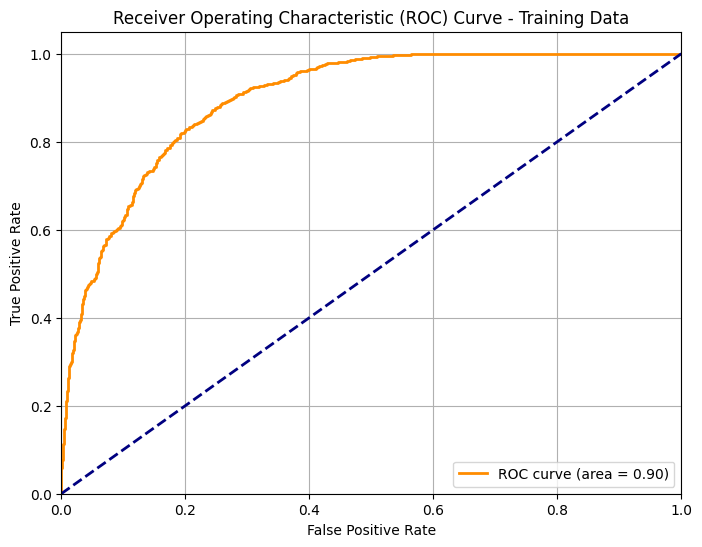

In [30]:
# prompt: 訓練データにおけるAUCカーブを描写

import matplotlib.pyplot as plt
# 訓練データに対するAUCカーブを描写
y_train_pred_proba = optimized_model.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_train_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Training Data')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


=== Feature Importances ===
                             Feature  Importance
1                                Age    0.238586
2                            Age_nan    0.154239
24                  Position_encoded    0.047851
5                     School_encoded    0.043086
6              Sprint_40yd_std_score    0.042308
11                 Shuttle_std_score    0.039953
13                  Weight_std_score    0.039912
8         Bench_Press_Reps_std_score    0.034472
10           Agility_3cone_std_score    0.033819
22               Player_Type_offense    0.032506
7            Vertical_Jump_std_score    0.031520
9               Broad_Jump_std_score    0.031334
14     Position_Type_backs_receivers    0.030833
3            physical_test_nan_count    0.026988
21               Player_Type_defense    0.026249
12                  Height_std_score    0.026215
15      Position_Type_defensive_back    0.025696
0                               Year    0.024408
19   Position_Type_offensive_lineman    

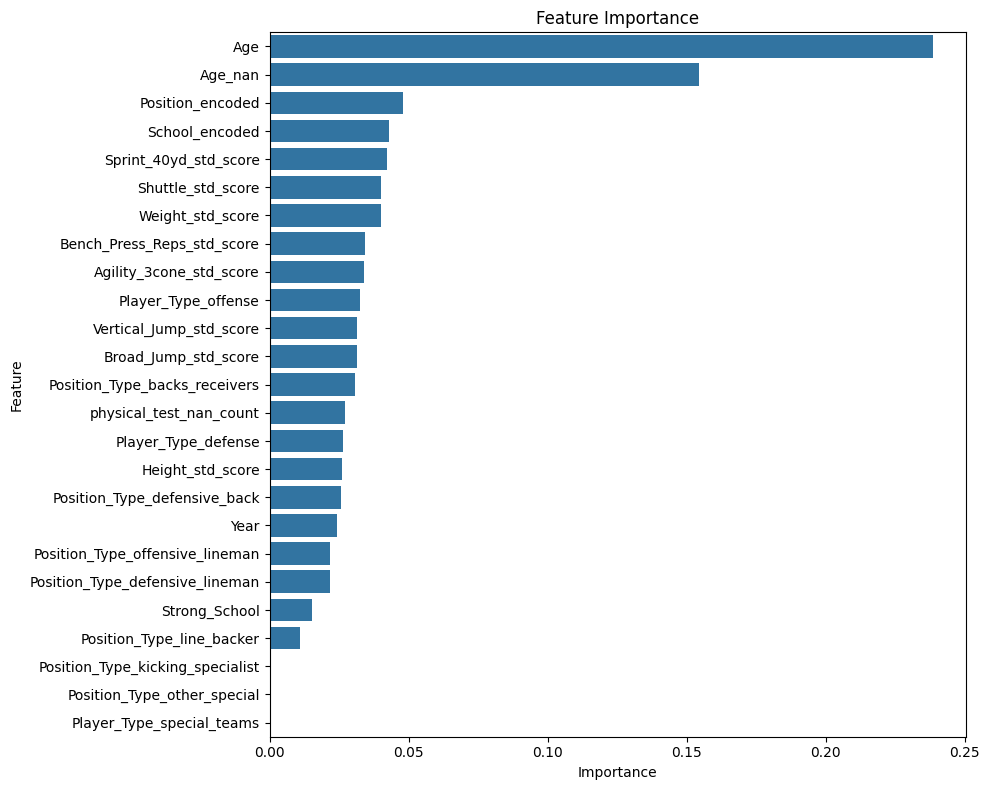

In [32]:
# 特徴量重要度を取得
feature_importances = optimized_model.feature_importances_

# 特徴量名と重要度を組み合わせる
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 重要度で降順にソート
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 結果を表示
print("\n=== Feature Importances ===")
print(importance_df)

# 特徴量重要度を可視化 (オプション)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [34]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！